In [1]:
import copy
import torch
from torch import nn
import pandas as pd
import gc
from tqdm import tqdm
import matplotlib.pyplot as plt

steps = [128, 256, 384, 512, 640, 768, 896, 1024]


In [2]:
def _materialize_optim_tensor(x):
    """Unwrap DTensor to plain CPU Tensor. DTensor subclasses torch.Tensor — check it first."""
    try:
        from torch.distributed.tensor import DTensor
    except ImportError:
        DTensor = None  # type: ignore[misc, assignment]

    if DTensor is not None and isinstance(x, DTensor):
        x = x.to_local()
    elif getattr(type(x), "__name__", "") == "DTensor" and callable(getattr(x, "to_local", None)):
        x = x.to_local()

    if isinstance(x, torch.Tensor):
        return x.detach().cpu().contiguous()

    ft = getattr(x, "full_tensor", None)
    if callable(ft):
        try:
            y = ft()
            if DTensor is not None and isinstance(y, DTensor):
                y = y.to_local()
            if isinstance(y, torch.Tensor):
                return y.detach().cpu().contiguous()
        except Exception:
            pass
    lt = getattr(x, "local_tensor", None)
    if callable(lt):
        y = lt()
        if DTensor is not None and isinstance(y, DTensor):
            y = y.to_local()
        if isinstance(y, torch.Tensor):
            return y.detach().cpu().contiguous()
    return x


def _merge_optimizer_tensor_values(per_rank_vals):
    """Merge one optimizer-state entry (e.g. exp_avg) across FSDP ranks."""
    tensors = []
    for v in per_rank_vals:
        if v is None:
            tensors.append(None)
            continue
        tensors.append(_materialize_optim_tensor(v))

    present = [(i, t) for i, t in enumerate(tensors) if t is not None]
    if not present:
        raise ValueError("no tensor/scalar present for this key across ranks")

    first = present[0][1]
    if not isinstance(first, torch.Tensor):
        ref = first
        for _, t in present[1:]:
            if t != ref:
                raise ValueError(f"scalar mismatch across ranks: {ref!r} vs {t!r}")
        return ref

    if first.ndim == 0:
        ref = first.item()
        for _, t in present[1:]:
            assert isinstance(t, torch.Tensor) and t.ndim == 0
            if t.item() != ref:
                raise ValueError(f"scalar tensor mismatch: {ref} vs {t.item()}")
        return first.clone()

    chunks = [t for _, t in present]
    if len(chunks) == 1:
        return chunks[0].clone()
    # FSDP shards optimizer tensors along the flattened parameter dimension
    return torch.cat(chunks, dim=0)


def merge_sharded_optimizer_state_dicts(shard_dicts):
    """
    Merge VERL `optim_world_size_W_rank_r.pt` shards (FSDP SHARDED_STATE_DICT).

    - `param_groups` are taken from rank 0 (should match all ranks).
    - For each optimizer param id, tensor entries are concatenated in rank order when
      multiple ranks contribute shards; scalars are deduplicated with equality checks.
    """
    if not shard_dicts:
        raise ValueError("shard_dicts is empty")

    merged = {
        "state": {},
        "param_groups": copy.deepcopy(shard_dicts[0]["param_groups"]),
    }

    all_ids = set()
    for d in shard_dicts:
        all_ids |= set(d.get("state", {}))

    for pid in sorted(all_ids):
        per_rank_states = [d.get("state", {}).get(pid) for d in shard_dicts]
        keys = set()
        for st in per_rank_states:
            if st:
                keys |= set(st.keys())

        merged_state = {}
        for k in sorted(keys):
            per_rank_vals = [st.get(k) if st else None for st in per_rank_states]
            if all(v is None for v in per_rank_vals):
                continue
            merged_state[k] = _merge_optimizer_tensor_values(per_rank_vals)
        merged["state"][pid] = merged_state

    return merged


WORLD_SIZE = 4

def get_merged_optim_dict(ckpt_actor_dir, world_size: int = 4):
    shard_dicts = []
    for rank in range(world_size):
        path = f"{ckpt_actor_dir}/optim_world_size_{world_size}_rank_{rank}.pt"
        shard_dicts.append(torch.load(path, map_location="cpu", weights_only=False))

    optim_dict = merge_sharded_optimizer_state_dicts(shard_dicts)
    return optim_dict

In [8]:
from collections import defaultdict
from tqdm import tqdm

all_eff_step_sizes = defaultdict(list)
for i in tqdm(steps):
    CKPT_ACTOR_DIR = f"checkpoints/Pretrain-sharpen/OLMo-150M-constant-gsm8k-step60000/global_step_{i}/actor"
    optim_dict = get_merged_optim_dict(CKPT_ACTOR_DIR)
    betas = optim_dict['param_groups'][0]['betas']
    beta1 = betas[0]
    beta2 = betas[1]
    eps = optim_dict['param_groups'][0]['eps']

    for k in optim_dict['state'].keys():
        state = optim_dict['state'][k]
        step = state['step']
        exp_avg = state['exp_avg']
        corrected_exp_avg = state['exp_avg'] / (1 - beta1 ** step)
        exp_avg_sq = state['exp_avg_sq']
        corrected_exp_avg_sq = state['exp_avg_sq'] / (1 - beta2 ** step)
        eff_step_size = torch.mean(corrected_exp_avg / (torch.sqrt(corrected_exp_avg_sq) + eps)).item()
        all_eff_step_sizes[i].append(eff_step_size)
    
    del optim_dict
    torch.cuda.empty_cache()
    gc.collect()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:08<00:00,  1.07s/it]


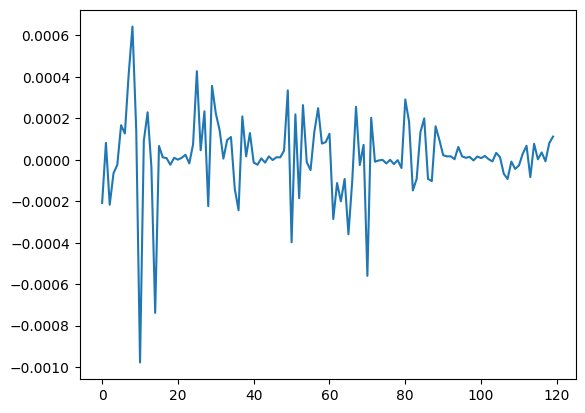

In [79]:
# fig, axs = plt.subplots(ncols=len(all_eff_step_sizes[128]) // 5, nrows=5, figsize=(40, 30))
i = -4

for step in [128, 256, 384, 512, 640, 768, 896, 1024]:
    checks.append(all_eff_step_sizes[step][i])
plt.plot(checks)

ValueError: not enough values to unpack (expected 2, got 0)

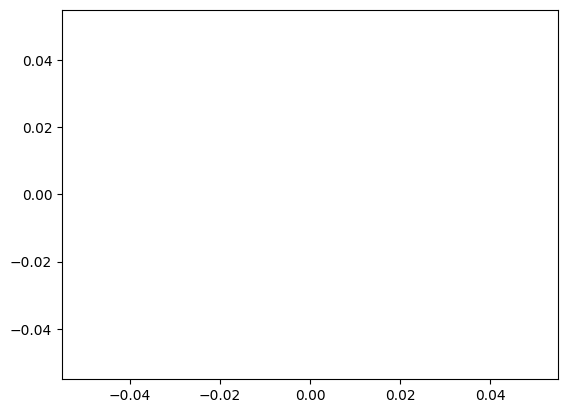